In [1]:
import pandas as pd

btc = pd.read_csv(
    "/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw_tp/BTCUSDT_klines_5m.csv"
)

In [2]:
# Update Close Time and Open Time columns if values are less than 2000000000000
btc["Close Time"] = btc["Close Time"].apply(
    lambda x: x * 1000 + 999 if x < 2000000000000 else x
)
btc["Open Time"] = btc["Open Time"].apply(
    lambda x: x * 1000 if x < 2000000000000 else x
)

In [3]:
ema_fast = btc["Close"].ewm(span=60, adjust=False).mean()
ema_slow = btc["Close"].ewm(span=360, adjust=False).mean()
btc["MACD"] = ema_fast - ema_slow
btc["Signal"] = btc["MACD"].ewm(span=9, adjust=False).mean()
btc["Hist"] = btc["MACD"] - btc["Signal"]

In [5]:
btc

,Close Time,index,Open Time,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore,MACD,Signal,Hist
0,1546301099999999,0,1546300800000000,3701.23,3703.72,3695.00,3696.32,85.572181,3.165206e+05,576,52.847931,1.954699e+05,0,0.000000,0.000000,0.000000
1,1546301399999999,1,1546301100000000,3696.30,3697.24,3689.88,3692.34,62.296581,2.300650e+05,384,28.365002,1.047693e+05,0,-0.108442,-0.021688,-0.086754
2,1546301699999999,2,1546301400000000,3692.34,3698.93,3692.34,3697.31,43.105333,1.593292e+05,365,24.852534,9.186500e+04,0,-0.077311,-0.032813,-0.044498
3,1546301999999999,3,1546301700000000,3697.91,3698.75,3693.00,3693.00,48.551084,1.794413e+05,397,28.603340,1.057210e+05,0,-0.164788,-0.059208,-0.105580
4,1546302299999999,4,1546302000000000,3693.44,3695.98,3690.92,3692.18,47.706443,1.761599e+05,391,21.783566,8.044333e+04,0,-0.271240,-0.101614,-0.169625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700461,1756683599999999,700461,1756683300000000,108251.22,108416.35,108111.00,108156.01,113.690770,1.230942e+07,16780,65.432640,7.086852e+06,0,44.282926,95.276049,-50.993123
700462,1756683899999999,700462,1756683600000000,108156.00,108258.00,108076.93,108258.00,102.716220,1.110862e+07,13502,56.703240,6.131969e+06,0,27.639700,81.748779,-54.109079
700463,1756684199999999,700463,1756683900000000,108257.99,108356.05,108194.86,108283.23,86.464520,9.361689e+06,12602,53.262880,5.766744e+06,0,12.313750,67.861773,-55.548023
700464,1756684499999999,700464,1756684200000000,108283.23,108291.81,108167.34,108232.18,45.644440,4.940206e+06,10319,18.244850,1.974705e+06,0,-3.820767,53.525265,-57.346032


In [6]:
# 将时间戳转换为 datetime 格式
btc["Close Time"] = pd.to_datetime(btc["Close Time"], unit="us")
btc["Open Time"] = pd.to_datetime(btc["Open Time"], unit="us")

# 设置索引
btc.set_index("Close Time", inplace=True)

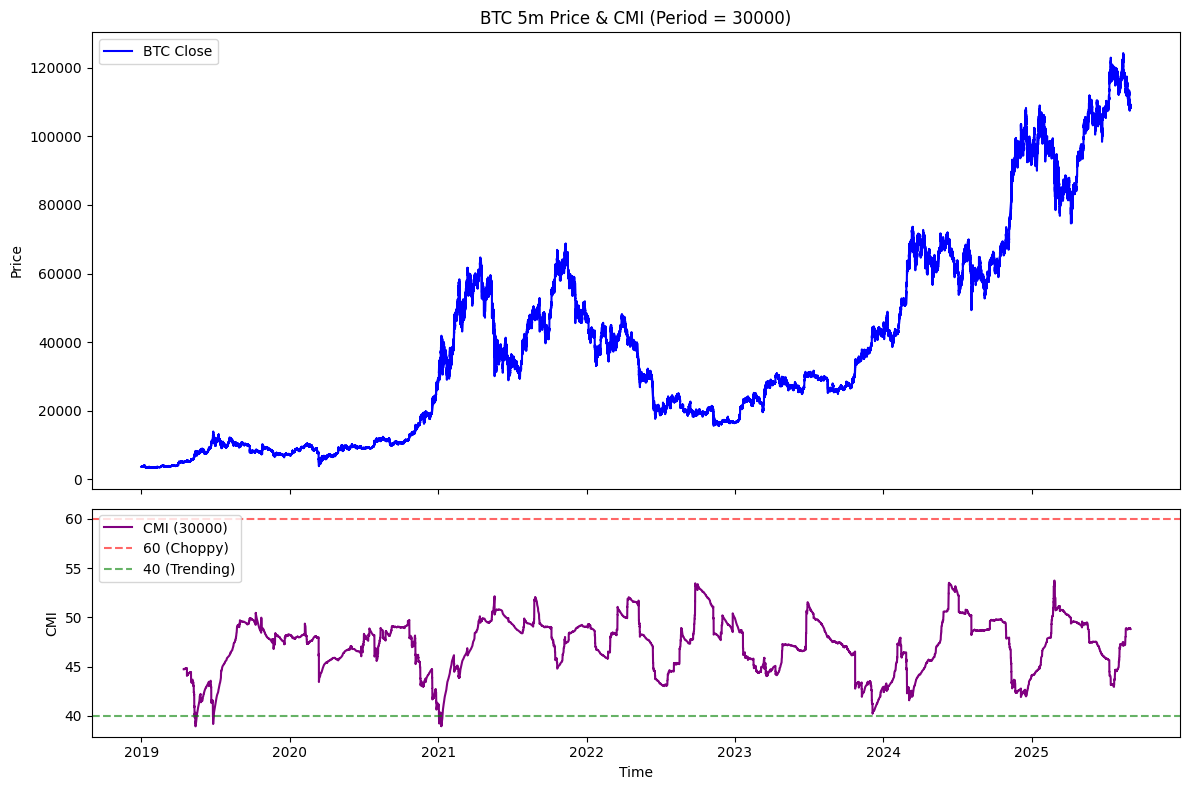

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def calc_cmi(btc: pd.DataFrame, n: int = 14) -> pd.Series:
    """标准 CMI 计算，需要 High/Low/Close"""
    prev_close = btc["Close"].shift(1)
    tr = pd.concat(
        [
            btc["High"] - btc["Low"],
            (btc["High"] - prev_close).abs(),
            (btc["Low"] - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)

    tr_sum = tr.rolling(window=n).sum()
    high_n = btc["High"].rolling(window=n).max()
    low_n = btc["Low"].rolling(window=n).min()

    cmi = 100 * (np.log10(tr_sum) - np.log10(high_n - low_n)) / np.log10(n)
    return cmi


long_n = 30000  # 60根5m = 300分钟 ≈ 5小时

btc["CMI_long"] = calc_cmi(btc, n=long_n)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# 价格
ax1.plot(btc.index, btc["Close"], color="blue", label="BTC Close")
ax1.set_title(f"BTC 5m Price & CMI (Period = {long_n})")
ax1.set_ylabel("Price")
ax1.legend(loc="upper left")

# 长周期 CMI
ax2.plot(btc.index, btc["CMI_long"], color="purple", label=f"CMI ({long_n})")
ax2.axhline(60, color="red", linestyle="--", alpha=0.6, label="60 (Choppy)")
ax2.axhline(40, color="green", linestyle="--", alpha=0.6, label="40 (Trending)")
ax2.set_ylabel("CMI")
ax2.set_xlabel("Time")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [7]:
# # Set the parameters
# past_window = 60     # 5 hours with 5-minute intervals
# future_start = 0   # 12.5 hours ahead
# future_end = 360     # 17.5 hours ahead
# THRESHOLD = -0.02
# MAX_HOLD = 10
# BULLET_SIZE = 4000
# INITIAL = 100000
# FEE = 0.0005


# Set the parameters
# btc = btc.loc['2024-01-01':'2024-07-01']
past_window = 60  # 5 hours with 5-minute intervals
future_start = 0  # 12.5 hours ahead
future_end = 360  # 17.5 hours ahead
THRESHOLD = -0.02
MAX_HOLD = 5
BULLET_SIZE = 1000
INITIAL = 10000
FEE = 0.0005

Calculating growth rates with parameters: past_window=60, future_start=0, future_end=360


100%|██████████| 700046/700046 [00:13<00:00, 50081.25it/s]



First few valid values of past growth rate:
Close Time
2019-01-01 05:04:59.999999    0.000106
2019-01-01 05:09:59.999999    0.001303
2019-01-01 05:14:59.999999    0.001177
2019-01-01 05:19:59.999999    0.002172
2019-01-01 05:24:59.999999    0.002481
dtype: float64

First few valid values of future growth rate:
Close Time
2019-01-01 05:04:59.999999    0.022604
2019-01-01 05:09:59.999999    0.024148
2019-01-01 05:14:59.999999    0.022568
2019-01-01 05:19:59.999999    0.022402
2019-01-01 05:24:59.999999    0.026288
dtype: float64


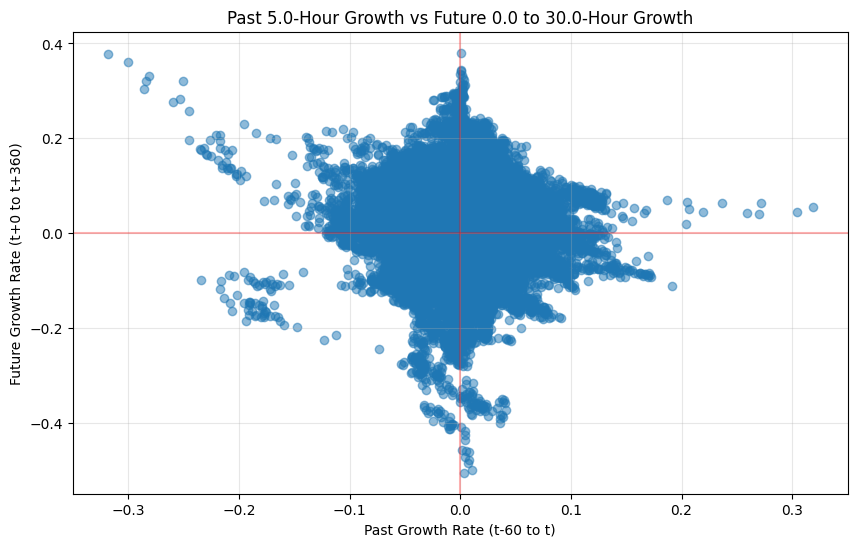


Correlation coefficient between past and future growth rates: -0.0152

Merged results example:
                              Close  past_growth_rate  future_growth_rate
Close Time                                                               
2019-01-01 05:04:59.999999  3696.71          0.000106            0.022604
2019-01-01 05:09:59.999999  3697.15          0.001303            0.024148
2019-01-01 05:14:59.999999  3701.66          0.001177            0.022568
2019-01-01 05:19:59.999999  3701.02          0.002172            0.022402
2019-01-01 05:24:59.999999  3701.34          0.002481            0.026288


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm


# Calculate past and future growth rates with configurable parameters
def calculate_all_growth_rates(btc, past_window=60, future_start=150, future_end=210):
    """Calculate two growth rates for each row in the BTC dataframe:
    1. Past growth rate (t-past_window to t)
    2. Future growth rate (t+future_start to t+future_end)

    Parameters:
    -----------
    btc : pd.DataFrame
        DataFrame containing BTC price data with 'Close' column
    past_window : int
        Number of time steps to look back for past growth calculation
    future_start : int
        Starting point for future window (time steps after current point)
    future_end : int
        Ending point for future window (time steps after current point)

    Returns:
    --------
    tuple of pd.Series
        Two Series with the same index as the original dataframe
    """
    # Create empty Series with the same index as btc
    past_growth_series = pd.Series(index=btc.index, dtype=float)
    future_growth_series = pd.Series(index=btc.index, dtype=float)

    # Get Close column as numpy array for better performance
    close_values = btc["Close"].values

    # Calculate growth rates for all valid indices
    valid_range = range(past_window, len(btc) - future_end)

    print(
        f"Calculating growth rates with parameters: past_window={past_window}, future_start={future_start}, future_end={future_end}"
    )
    for t in tqdm(valid_range):
        # Calculate past growth rate (t-past_window to t)
        past_growth = (close_values[t] - close_values[t - past_window]) / close_values[
            t - past_window
        ]

        # Calculate future growth rate (t+future_start to t+future_end)
        future_growth = (
            close_values[t + future_end] - close_values[t + future_start]
        ) / close_values[t + future_start]

        # Store at corresponding index position
        past_growth_series.iloc[t] = past_growth
        future_growth_series.iloc[t] = future_growth

    return past_growth_series, future_growth_series


holding_period = future_end - future_start  # Holding period for future growth

# Apply function to calculate growth rates
past_growth, future_growth = calculate_all_growth_rates(
    btc, past_window, future_start, future_end
)

# Print the first few valid values to verify
print("\nFirst few valid values of past growth rate:")
print(past_growth.dropna().head())

print("\nFirst few valid values of future growth rate:")
print(future_growth.dropna().head())

# Create scatter plot showing relationship between past and future growth rates
valid_data = pd.DataFrame(
    {"past_growth": past_growth, "future_growth": future_growth}
).dropna()

# Time descriptions for plot labels
past_hours = past_window * 5 / 60  # Convert 5-minute intervals to hours
future_start_hours = future_start * 5 / 60
future_end_hours = future_end * 5 / 60

plt.figure(figsize=(10, 6))
plt.scatter(valid_data["past_growth"], valid_data["future_growth"], alpha=0.5)
plt.axhline(y=0, color="r", linestyle="-", alpha=0.3)
plt.axvline(x=0, color="r", linestyle="-", alpha=0.3)
plt.title(
    f"Past {past_hours:.1f}-Hour Growth vs Future {future_start_hours:.1f} to {future_end_hours:.1f}-Hour Growth"
)
plt.xlabel(f"Past Growth Rate (t-{past_window} to t)")
plt.ylabel(f"Future Growth Rate (t+{future_start} to t+{future_end})")
plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation coefficient
correlation = valid_data["past_growth"].corr(valid_data["future_growth"])
print(
    f"\nCorrelation coefficient between past and future growth rates: {correlation:.4f}"
)

# Save results
result_df = pd.DataFrame(
    {
        "Close": btc["Close"],
        "past_growth_rate": past_growth,
        "future_growth_rate": future_growth,
    }
)

# Output a few strategies for inspection
print("\nMerged results example:")
print(result_df.dropna().head())

Processing: 100%|██████████| 700466/700466 [00:03<00:00, 224019.88it/s]


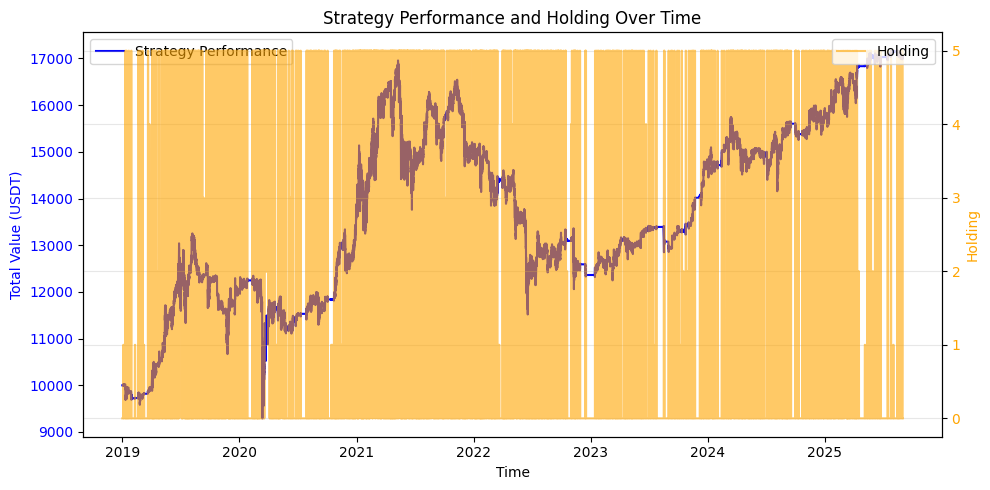

In [10]:
from collections import deque

import pandas as pd


def implement_strategy(
    btc: pd.DataFrame,
    past_growth: pd.Series,
    future_growth: pd.Series,
    holding_period: int,
    threshold: float = 0.01,
    initial_cap: float = 100000,
    trade_size: float = 1000,
    fee: float = 0.001,
    max_hold: int = 5,
):
    """更稳健的策略实现：存储订单历史，到期自动清仓

    Parameters
    ----------
    btc : pd.DataFrame
        带有 'Close' 列的BTC价格数据
    past_growth, future_growth : pd.Series
        历史与未来涨幅
    holding_period : int
        持仓期(单位与btc的时间索引一致)
    threshold : float
        买入阈值
    initial_cap : float
        初始资金
    trade_size : float
        每次交易的USDT金额
    fee : float
        单边手续费比例
    max_hold : int
        最大持仓单数
    """
    prices = btc["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap  # USDT
    amount = 0.0  # 持仓BTC数量
    open_orders = deque()  # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if (
            t >= 1
            and not np.isnan(past_growth.iloc[t])
            and past_growth.iloc[t] < threshold
            and now_holding < max_hold
            # and not btc['Freeze'].iloc[t]  # 如果在冻结期内，不买入
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        # --- 到期清仓 ---
        while open_orders and (t - open_orders[0]["time"]) >= holding_period:
            order = open_orders.popleft()
            sell_qty = order["qty"]
            sell_revenue = sell_qty * price_t * (1 - fee)

            capital += sell_revenue
            amount -= sell_qty
            now_holding -= 1

            pnl = (
                (price_t - order["price"]) - (order["price"] + price_t) * fee
            ) / order["price"]
            pnl_records[t] = pnl

    # 生成结果
    performance_df = pd.DataFrame({"Total Value": total_value}, index=btc.index)
    holding_series = pd.Series(holdings_array, index=btc.index)
    pnl_series = pd.Series(pnl_records, index=btc.index)
    return performance_df, pnl_series, holding_series


# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(
    btc,
    past_growth,
    future_growth,
    holding_period,
    threshold=THRESHOLD,
    initial_cap=INITIAL,
    max_hold=MAX_HOLD,
    fee=FEE,
    trade_size=BULLET_SIZE,
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数


# 策略表现
ax1.plot(
    holding.index,
    strategy_performance["Total Value"],
    label="Strategy Performance",
    color="blue",
)
ax1.set_ylabel("Total Value (USDT)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# 持仓
ax2.plot(holding.index, holding.values, label="Holding", color="orange", alpha=0.6)
ax2.set_ylabel("Holding", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Strategy Performance and Holding Over Time")
ax1.set_xlabel("Time")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 打印前几行以验证
print(non_zero_pnls.head())

Close Time
2024-09-03 05:49:59.999999    0.032624
2024-09-03 05:54:59.999999    0.031948
2024-09-03 05:59:59.999999    0.031865
2024-09-03 06:04:59.999999    0.028328
2024-09-03 06:09:59.999999    0.028744
dtype: float64


In [ ]:
# 将 pnls 转换为 numpy 数组以便计算

pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0])
    / abs(np.mean(pnls_array[pnls_array < 0]))
    if np.any(pnls_array < 0)
    else float("inf"),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array)
    if np.std(pnls_array) > 0
    else 0,
    "总收益率": np.sum(pnls_array),
}

# 打印统计指标
for key, value in stats.items():
    print(
        f"{key}: {value:.4f}"
        if isinstance(value, (float, np.float64))
        else f"{key}: {value}"
    )

总交易次数: 401
平均收益率: 0.0040
中位数收益率: 0.0036
最大收益率: 0.0936
最小收益率: -0.1002
标准差: 0.0279
正收益交易数: 228
负收益交易数: 173
胜率: 0.5686
盈亏比: 1.1062
夏普比率: 0.1444
总收益率: 1.6148


每次回撤的描述：
                         Start                        End  Max Drawdown
0   2024-09-01 23:59:59.999999 2024-09-02 00:04:59.999999     -0.000047
1   2024-09-02 00:09:59.999999 2024-09-02 00:14:59.999999     -0.000333
2   2024-09-02 00:39:59.999999 2024-09-02 02:19:59.999999     -0.003072
3   2024-09-02 02:24:59.999999 2024-09-02 03:19:59.999999     -0.003171
4   2024-09-02 03:29:59.999999 2024-09-02 03:39:59.999999     -0.000661
..                         ...                        ...           ...
135 2025-07-25 23:24:59.999999 2025-07-25 23:39:59.999999     -0.000166
136 2025-07-25 23:44:59.999999 2025-07-25 23:49:59.999999     -0.000056
137 2025-07-25 23:54:59.999999 2025-07-25 23:59:59.999999     -0.000220
138 2025-07-26 00:04:59.999999 2025-07-26 02:34:59.999999     -0.001693
139 2025-07-26 02:39:59.999999 2025-08-14 13:14:59.999999     -0.003490

[140 rows x 3 columns]


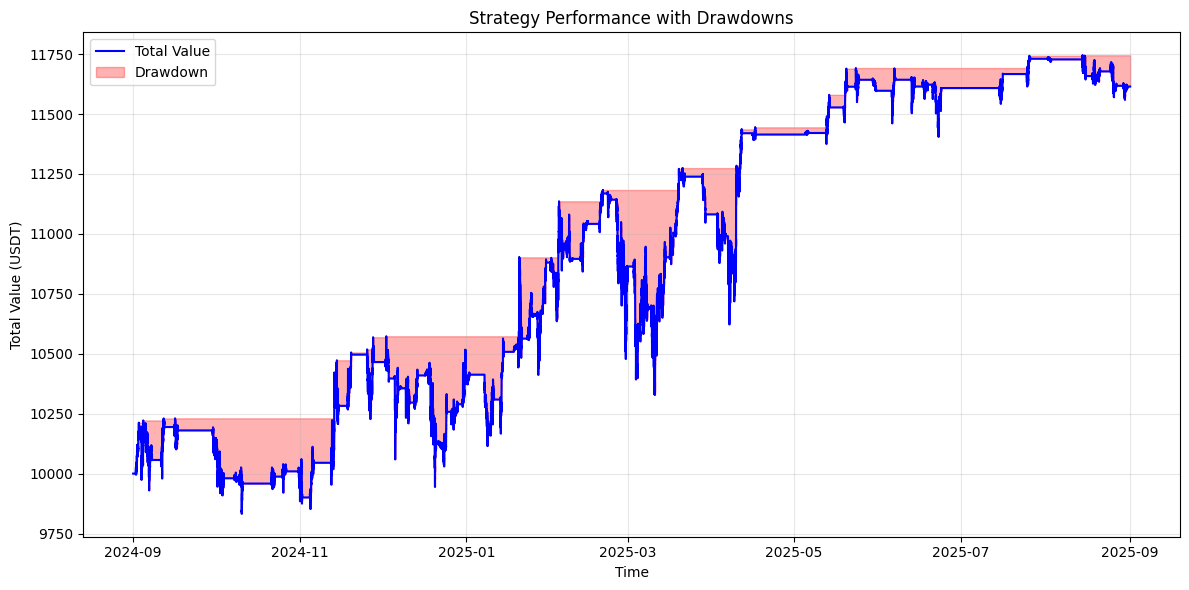

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 计算回撤
strategy_performance["Peak"] = strategy_performance["Total Value"].cummax()
strategy_performance["Drawdown"] = (
    strategy_performance["Total Value"] / strategy_performance["Peak"] - 1
)

# 标记回撤开始和结束
strategy_performance["Drawdown Start"] = (strategy_performance["Drawdown"] < 0) & (
    strategy_performance["Drawdown"].shift(1) == 0
)
strategy_performance["Drawdown End"] = (strategy_performance["Drawdown"] == 0) & (
    strategy_performance["Drawdown"].shift(1) < 0
)

# 提取每次回撤的开始和结束时间
drawdown_periods = []
current_start = None

for idx, row in strategy_performance.iterrows():
    if row["Drawdown Start"]:
        current_start = idx
    elif row["Drawdown End"] and current_start is not None:
        drawdown_periods.append((current_start, idx))
        current_start = None

# 描述每次回撤的幅度
drawdown_descriptions = []
for start, end in drawdown_periods:
    drawdown_max = strategy_performance.loc[start:end, "Drawdown"].min()
    drawdown_descriptions.append(
        {"Start": start, "End": end, "Max Drawdown": drawdown_max}
    )

# 转换为 DataFrame
drawdown_df = pd.DataFrame(drawdown_descriptions)
print("每次回撤的描述：")
print(drawdown_df)

# 可视化回撤
plt.figure(figsize=(12, 6))
plt.plot(strategy_performance["Total Value"], label="Total Value", color="blue")
plt.fill_between(
    strategy_performance.index,
    strategy_performance["Total Value"],
    strategy_performance["Peak"],
    color="red",
    alpha=0.3,
    label="Drawdown",
)
plt.title("Strategy Performance with Drawdowns")
plt.xlabel("Time")
plt.ylabel("Total Value (USDT)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

每次回撤的描述：
                         Start                        End  Max Drawdown
0   2024-09-01 23:59:59.999999 2024-09-02 00:04:59.999999     -0.000047
1   2024-09-02 00:09:59.999999 2024-09-02 00:14:59.999999     -0.000333
2   2024-09-02 00:39:59.999999 2024-09-02 02:19:59.999999     -0.003072
3   2024-09-02 02:24:59.999999 2024-09-02 03:19:59.999999     -0.003171
4   2024-09-02 03:29:59.999999 2024-09-02 03:39:59.999999     -0.000661
..                         ...                        ...           ...
135 2025-07-25 23:24:59.999999 2025-07-25 23:39:59.999999     -0.000166
136 2025-07-25 23:44:59.999999 2025-07-25 23:49:59.999999     -0.000056
137 2025-07-25 23:54:59.999999 2025-07-25 23:59:59.999999     -0.000220
138 2025-07-26 00:04:59.999999 2025-07-26 02:34:59.999999     -0.001693
139 2025-07-26 02:39:59.999999 2025-08-14 13:14:59.999999     -0.003490

[140 rows x 3 columns]


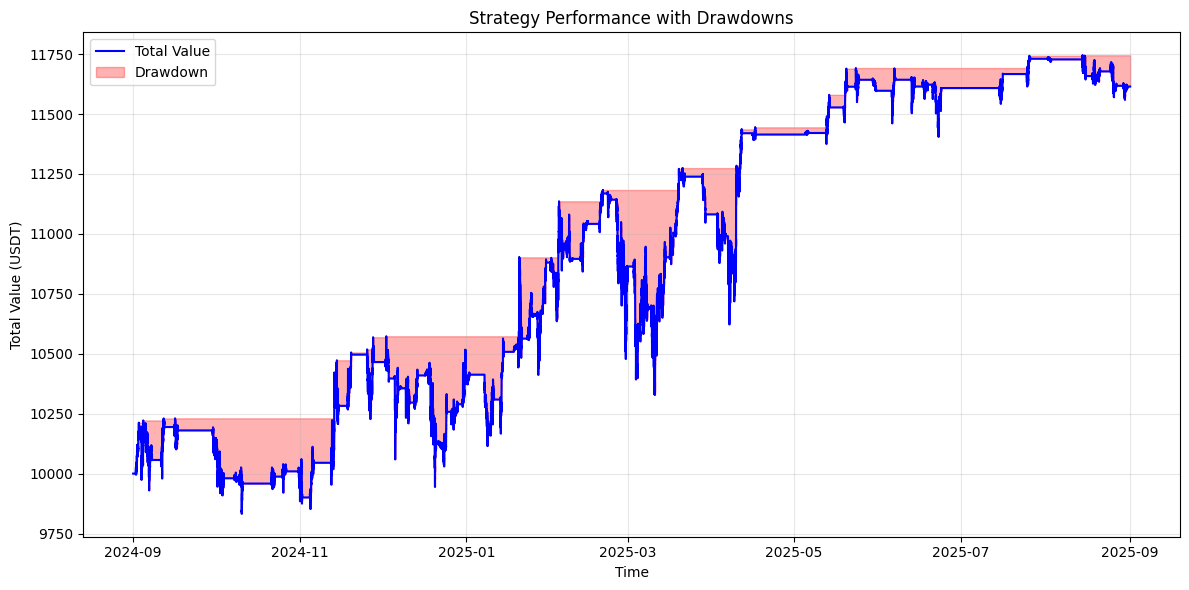

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 计算回撤
strategy_performance["Peak"] = strategy_performance["Total Value"].cummax()
strategy_performance["Drawdown"] = (
    strategy_performance["Total Value"] / strategy_performance["Peak"] - 1
)

# 标记回撤开始和结束
strategy_performance["Drawdown Start"] = (strategy_performance["Drawdown"] < 0) & (
    strategy_performance["Drawdown"].shift(1) == 0
)
strategy_performance["Drawdown End"] = (strategy_performance["Drawdown"] == 0) & (
    strategy_performance["Drawdown"].shift(1) < 0
)

# 提取每次回撤的开始和结束时间
drawdown_periods = []
current_start = None

for idx, row in strategy_performance.iterrows():
    if row["Drawdown Start"]:
        current_start = idx
    elif row["Drawdown End"] and current_start is not None:
        drawdown_periods.append((current_start, idx))
        current_start = None

# 描述每次回撤的幅度
drawdown_descriptions = []
for start, end in drawdown_periods:
    drawdown_max = strategy_performance.loc[start:end, "Drawdown"].min()
    drawdown_descriptions.append(
        {"Start": start, "End": end, "Max Drawdown": drawdown_max}
    )

# 转换为 DataFrame
drawdown_df = pd.DataFrame(drawdown_descriptions)
print("每次回撤的描述：")
print(drawdown_df)

# 可视化回撤
plt.figure(figsize=(12, 6))
plt.plot(strategy_performance["Total Value"], label="Total Value", color="blue")
plt.fill_between(
    strategy_performance.index,
    strategy_performance["Total Value"],
    strategy_performance["Peak"],
    color="red",
    alpha=0.3,
    label="Drawdown",
)
plt.title("Strategy Performance with Drawdowns")
plt.xlabel("Time")
plt.ylabel("Total Value (USDT)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
""

''

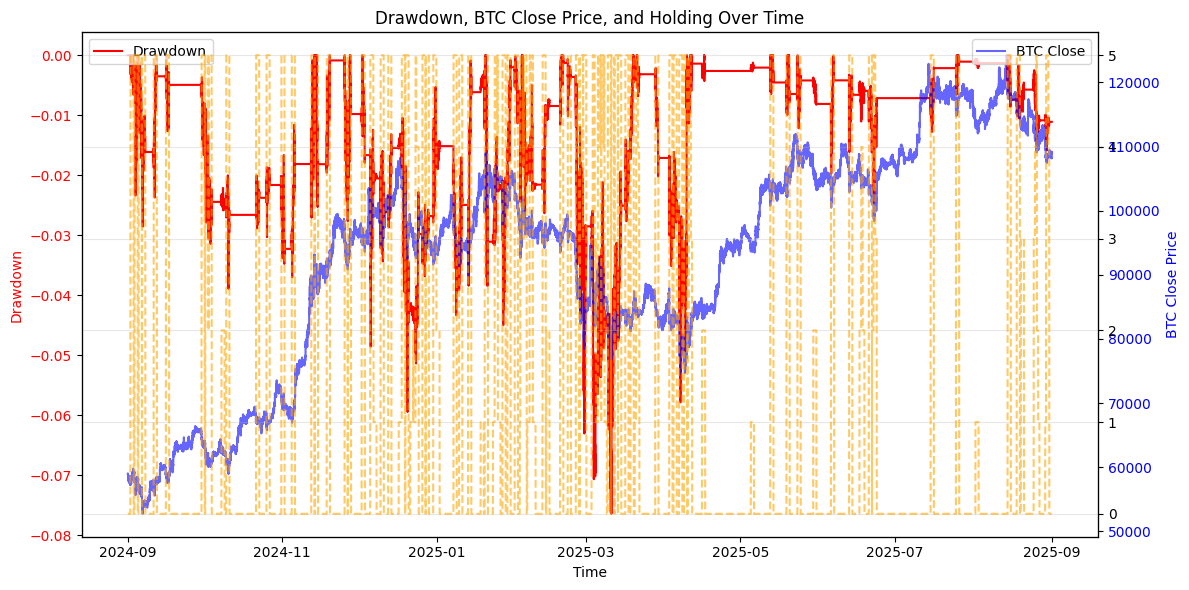

In [ ]:
import matplotlib.pyplot as plt

# 定义时间筛选范围
start_time = "2024-01-01"
end_time = "2029-07-01"

# 筛选数据
filtered_strategy_performance = strategy_performance.loc[start_time:end_time]
filtered_btc = btc.loc[start_time:end_time]
filtered_holding = holding.loc[start_time:end_time]

plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# 绘制 Drawdown
ax1.plot(
    filtered_strategy_performance.index,
    filtered_strategy_performance["Drawdown"],
    label="Drawdown",
    color="red",
)
ax1.set_ylabel("Drawdown", color="red")
ax1.tick_params(axis="y", labelcolor="red")

# 绘制 BTC 的 Close 列
ax2.plot(
    filtered_btc.index,
    filtered_btc["Close"],
    label="BTC Close",
    color="blue",
    alpha=0.6,
)
ax2.set_ylabel("BTC Close Price", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

# 绘制 Holding
ax3.plot(
    filtered_holding.index,
    filtered_holding.values,
    label="Holding",
    color="orange",
    alpha=0.6,
    linestyle="--",
)

# 设置标题和网格
plt.title("Drawdown, BTC Close Price, and Holding Over Time")
ax1.set_xlabel("Time")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()